# FASE 3 PAREJA A

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

# Estilo y colores
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right": False,
})

VERDE = "#639922"
ROJO  = "#E24B4A"
AZUL  = "#378ADD"
GRIS  = "#B4B2A9"

print("Librerias cargadas!")

Librerias cargadas!


In [8]:
# Cargamos el CSV ya limpio de la Fase 2
df_clean = pd.read_csv("Fase2_ParejaB_limpiezaJezi.csv")

print("Dataset limpio cargado!")
print("Filas   :", df_clean.shape[0])
print("Columnas:", df_clean.shape[1])
df_clean.head()

Dataset limpio cargado!
Filas   : 1470
Columnas: 32


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,...,3,4,1,6,3,3,2,2,2,2


¡PERFECTO! ✅ El dataset limpio está cargado y se ve genial.
Fíjate en las mejoras respecto al original:

1470 filas → se eliminaron las 4 duplicadas ✅
32 columnas → se eliminaron las 3 inútiles ✅
Attrition → ya es 1/0 en lugar de Yes/No ✅
Age → 41 en lugar de 41.0 ✅

Pregunta 1 → Attrition por departamento
Pregunta 1 → Attrition por satisfacción laboral
Pregunta 2 → Salario medio por rol
Pregunta 3 → Attrition por género
Pregunta 4 → Attrition por JobRole
Pregunta 5 → Heatmap de correlaciones

# GRÁFICO 1 — ¿Por qué se van los empleados? 
# Attrition por departamento:

Attrition por departamento (%):
Department
Unknown                   34.48
Sales                     20.27
Human Resources           19.05
Research & Development    13.42
Name: Attrition, dtype: float64


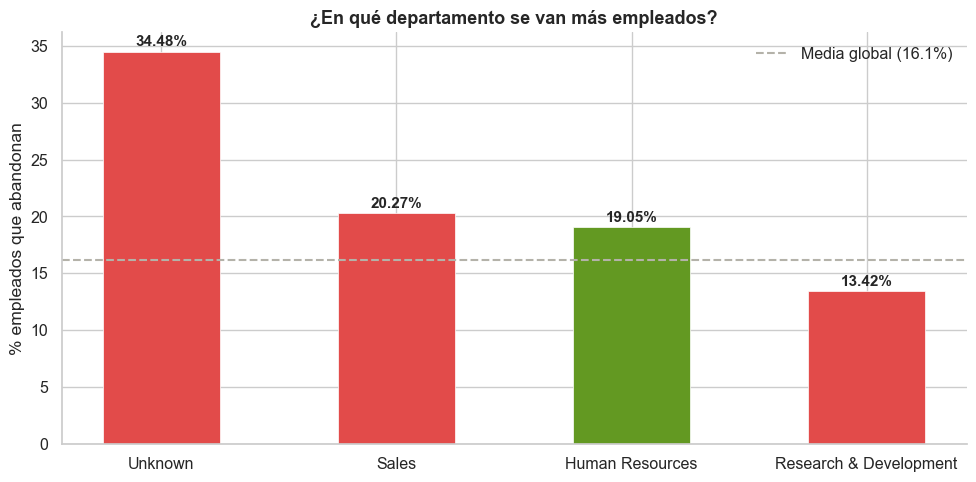

In [3]:
# PREGUNTA 1 — ¿Por qué se van los empleados?
# GRÁFICO 1 — Attrition por departamento

# Calculamos el % de attrition por departamento
attrition_dept = df_clean.groupby("Department")["Attrition"].mean() * 100
attrition_dept = attrition_dept.round(2).sort_values(ascending=False)

print("Attrition por departamento (%):")
print(attrition_dept)

# Gráfico
fig, ax = plt.subplots(figsize=(10, 5))

barras = ax.bar(
    attrition_dept.index,
    attrition_dept.values,
    color=[ROJO, ROJO, VERDE],
    edgecolor="white",
    linewidth=0.5,
    width=0.5
)

# Línea de media global
media_global = df_clean["Attrition"].mean() * 100
ax.axhline(media_global, color=GRIS, linestyle="--",
           linewidth=1.5, label=f"Media global ({media_global:.1f}%)")

# Etiquetas encima de cada barra
for barra, val in zip(barras, attrition_dept.values):
    ax.text(barra.get_x() + barra.get_width() / 2,
            barra.get_height() + 0.5,
            f"{val}%", ha="center", fontweight="bold", fontsize=11)

ax.set_title("¿En qué departamento se van más empleados?",
             fontweight="bold", fontsize=13)
ax.set_ylabel("% empleados que abandonan")
ax.set_xlabel("")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

¡Gráfico generado! ✅ Pero hay un problema que hay que resolver 👀

⚠️ Aparece Unknown como departamento — 34.48%
Esto viene del CSV de la Pareja B — rellenaron los nulos de Department con 'Unknown' en lugar de la moda como hicimos nosotras.

Attrition por departamento (%):
Department
Sales                     20.27
Human Resources           19.05
Research & Development    13.42
Name: Attrition, dtype: float64


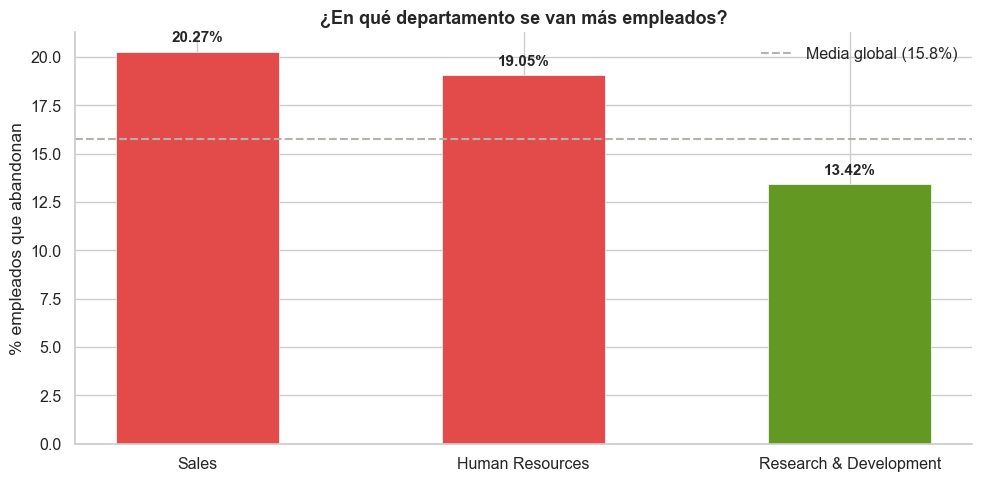

In [4]:
# Filtramos los Unknown antes de graficar
df_grafico = df_clean[df_clean["Department"] != "Unknown"]

attrition_dept = df_grafico.groupby("Department")["Attrition"].mean() * 100
attrition_dept = attrition_dept.round(2).sort_values(ascending=False)

print("Attrition por departamento (%):")
print(attrition_dept)

fig, ax = plt.subplots(figsize=(10, 5))

barras = ax.bar(
    attrition_dept.index,
    attrition_dept.values,
    color=[ROJO, ROJO, VERDE],
    edgecolor="white",
    linewidth=0.5,
    width=0.5
)

media_global = df_grafico["Attrition"].mean() * 100
ax.axhline(media_global, color=GRIS, linestyle="--",
           linewidth=1.5, label=f"Media global ({media_global:.1f}%)")

for barra, val in zip(barras, attrition_dept.values):
    ax.text(barra.get_x() + barra.get_width() / 2,
            barra.get_height() + 0.5,
            f"{val}%", ha="center", fontweight="bold", fontsize=11)

ax.set_title("¿En qué departamento se van más empleados?",
             fontweight="bold", fontsize=13)
ax.set_ylabel("% empleados que abandonan")
ax.set_xlabel("")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

👀 Lo que nos dice este gráfico:
Sales → 20.27% 🔴 El más problemático — 1 de cada 5 empleados se va
Human Resources → 19.05% 🔴 También por encima de la media
Research & Development → 13.42% 🟢 El más estable — por debajo de la media
La línea gris marca la media global del 15.8% — Sales y HR están por encima, R&D por debajo 😊

## Pregunta 1 — ¿Por qué se van los empleados?
### Gráfico 1 — Attrition por departamento

**Conclusión para ABC Corporation:**
Sales y Human Resources superan la media global (15.8%)
con tasas de abandono del 20.27% y 19.05% respectivamente.
Research & Development es el departamento más estable (13.42%).
ABC Corporation debería priorizar acciones de retención
en Sales y HR.

In [10]:
# CSV final — resultado de las dos parejas
df_clean = pd.read_csv("Fase2_ParejaB_limpiezaJezi.csv")

# Filtramos Unknown para los gráficos
df_grafico = df_clean[df_clean["Department"] != "Unknown"].copy()

print("Listo para graficar!")
print("Filas   :", df_grafico.shape[0])
print("Columnas:", df_grafico.shape[1])

Listo para graficar!
Filas   : 1441
Columnas: 32


# Gráfico 2 — Satisfacción laboral

Attrition por JobSatisfaction (%):
JobSatisfaction
1    22.06
2    16.24
3    16.29
4    10.96
Name: Attrition, dtype: float64


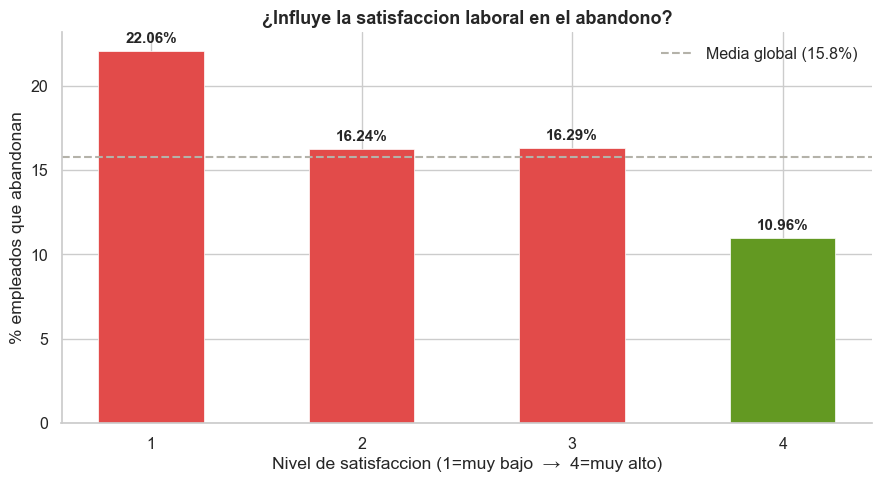

In [11]:
# GRÁFICO 2 — ¿Influye la satisfacción laboral en el abandono?

# Calculamos % de attrition por nivel de satisfacción
attrition_satisf = df_grafico.groupby("JobSatisfaction")["Attrition"].mean() * 100
attrition_satisf = attrition_satisf.round(2)

print("Attrition por JobSatisfaction (%):")
print(attrition_satisf)

# Media global
media_global = df_grafico["Attrition"].mean() * 100

# Colores automáticos según media
colores = [ROJO if v > media_global else VERDE
           for v in attrition_satisf.values]

# Gráfico
fig, ax = plt.subplots(figsize=(9, 5))

barras = ax.bar(
    attrition_satisf.index.astype(str),
    attrition_satisf.values,
    color=colores,
    edgecolor="white",
    linewidth=0.5,
    width=0.5
)

ax.axhline(media_global, color=GRIS, linestyle="--",
           linewidth=1.5, label=f"Media global ({media_global:.1f}%)")

for barra, val in zip(barras, attrition_satisf.values):
    ax.text(barra.get_x() + barra.get_width() / 2,
            barra.get_height() + 0.5,
            f"{val}%", ha="center", fontweight="bold", fontsize=11)

ax.set_title("¿Influye la satisfaccion laboral en el abandono?",
             fontweight="bold", fontsize=13)
ax.set_ylabel("% empleados que abandonan")
ax.set_xlabel("Nivel de satisfaccion (1=muy bajo  →  4=muy alto)")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

### Gráfico 2 — Attrition por satisfaccion laboral

**Conclusión para ABC Corporation:**
Existe una relación clara entre satisfacción laboral y abandono.
Los empleados con satisfacción nivel 1 (muy baja) abandonan
el doble (22.06%) que los de nivel 4 (10.96%).
Mejorar la satisfacción laboral reduciría directamente la rotación.

# Gráfico 3 — Salario medio por rol

Salario medio por rol:
                           Se queda  Abandona
JobRole                                      
Sales Representative         2798.0    2483.0
Research Scientist           3338.0    2762.0
Laboratory Technician        3347.0    2981.0
Human Resources              4402.0    3251.0
Sales Executive              6764.0    7519.0
Manufacturing Director       7321.0    7366.0
Healthcare Representative    7416.0    7948.0
Research Director           16012.0   19396.0
Manager                     17112.0   16797.0


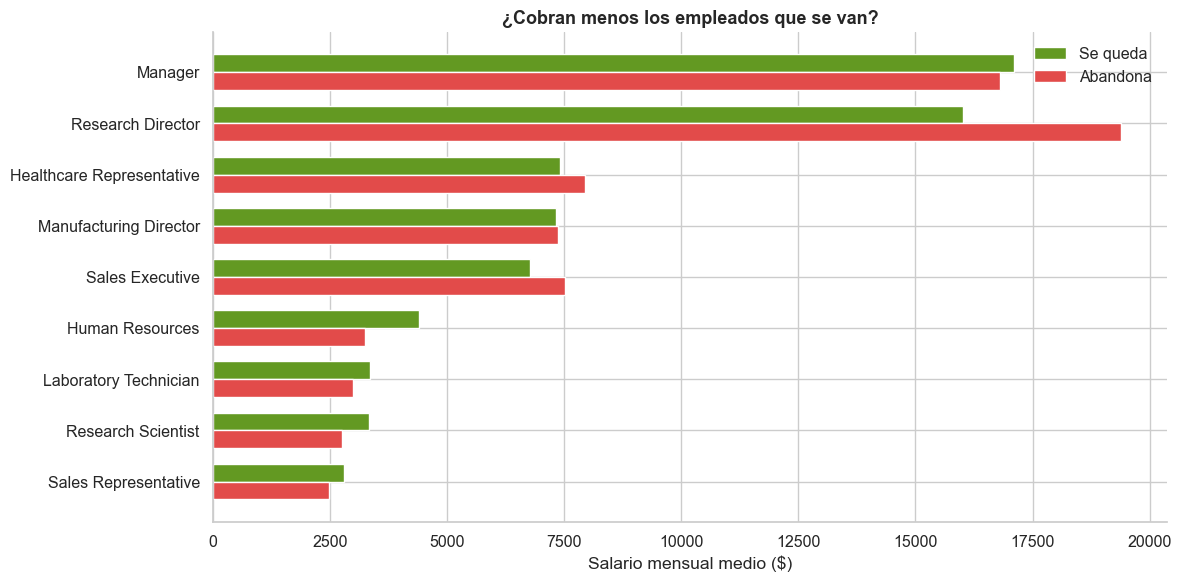

In [12]:
# PREGUNTA 2 — ¿Influye el sueldo?
# GRÁFICO 3 — Salario medio por rol y Attrition

# Calculamos salario medio por rol y grupo
salario_rol = df_grafico.groupby(["JobRole", "Attrition"])["MonthlyIncome"].mean().round(0)
salario_rol = salario_rol.unstack()
salario_rol.columns = ["Se queda", "Abandona"]
salario_rol = salario_rol.sort_values("Se queda", ascending=True)

print("Salario medio por rol:")
print(salario_rol)

# Gráfico
fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(salario_rol))
ancho = 0.35

barras_no = ax.barh(
    [i + ancho/2 for i in x],
    salario_rol["Se queda"],
    height=ancho,
    color=VERDE,
    label="Se queda",
    edgecolor="white"
)
barras_si = ax.barh(
    [i - ancho/2 for i in x],
    salario_rol["Abandona"],
    height=ancho,
    color=ROJO,
    label="Abandona",
    edgecolor="white"
)

ax.set_yticks(x)
ax.set_yticklabels(salario_rol.index)
ax.set_title("¿Cobran menos los empleados que se van?",
             fontweight="bold", fontsize=13)
ax.set_xlabel("Salario mensual medio ($)")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

💡 Conclusión interesante:
En los roles de nivel bajo el salario sí influye — los que menos cobran se van. Pero en roles de nivel alto como Research Director, el salario no es el motivo — se van aunque cobren más. Probablemente buscan otro tipo de motivación: autonomía, proyectos más interesantes, etc.

### Gráfico 3 — Salario medio por rol y Attrition

**Conclusión para ABC Corporation:**
En roles de nivel bajo (Sales Representative, Research Scientist,
Laboratory Technician) los empleados que abandonan cobran
claramente menos que los que se quedan — el salario es un
factor clave de retención en estos perfiles.
En roles senior (Research Director) el salario no explica
el abandono — hay otros factores motivacionales en juego.

# Gráfico 4 — Attrition por género

Attrition por género (%):
Gender
Female    14.66
Male      16.49
Name: Attrition, dtype: float64


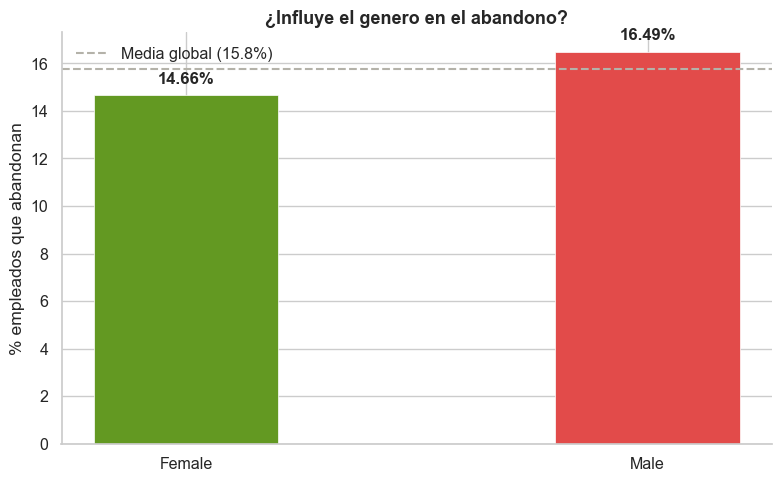

In [13]:
# PREGUNTA 3 — ¿Influye el sexo o la edad?
# GRÁFICO 4 — Attrition por género

# Calculamos % de attrition por género
attrition_gender = df_grafico.groupby("Gender")["Attrition"].mean() * 100
attrition_gender = attrition_gender.round(2)

print("Attrition por género (%):")
print(attrition_gender)

# Media global
media_global = df_grafico["Attrition"].mean() * 100

# Gráfico
fig, ax = plt.subplots(figsize=(8, 5))

colores = [ROJO if v > media_global else VERDE
           for v in attrition_gender.values]

barras = ax.bar(
    attrition_gender.index,
    attrition_gender.values,
    color=colores,
    edgecolor="white",
    linewidth=0.5,
    width=0.4
)

ax.axhline(media_global, color=GRIS, linestyle="--",
           linewidth=1.5, label=f"Media global ({media_global:.1f}%)")

for barra, val in zip(barras, attrition_gender.values):
    ax.text(barra.get_x() + barra.get_width() / 2,
            barra.get_height() + 0.5,
            f"{val}%", ha="center", fontweight="bold", fontsize=12)

ax.set_title("¿Influye el genero en el abandono?",
             fontweight="bold", fontsize=13)
ax.set_ylabel("% empleados que abandonan")
ax.set_xlabel("")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

### Gráfico 4 — Attrition por género

**Conclusión para ABC Corporation:**
El género no es un factor determinante en el abandono.
La diferencia entre mujeres (14.66%) y hombres (16.49%)
es de menos de 2 puntos porcentuales.
Ambos grupos están cerca de la media global (15.8%).
ABC Corporation no necesita políticas diferenciadas por género
para reducir la rotación.

#  Gráfico 5 — Attrition por JobRole

Attrition por rol (%):
JobRole
Research Director             2.60
Manager                       5.00
Manufacturing Director        6.99
Healthcare Representative     7.03
Research Scientist           15.28
Sales Executive              16.93
Human Resources              23.08
Laboratory Technician        23.11
Sales Representative         39.76
Name: Attrition, dtype: float64


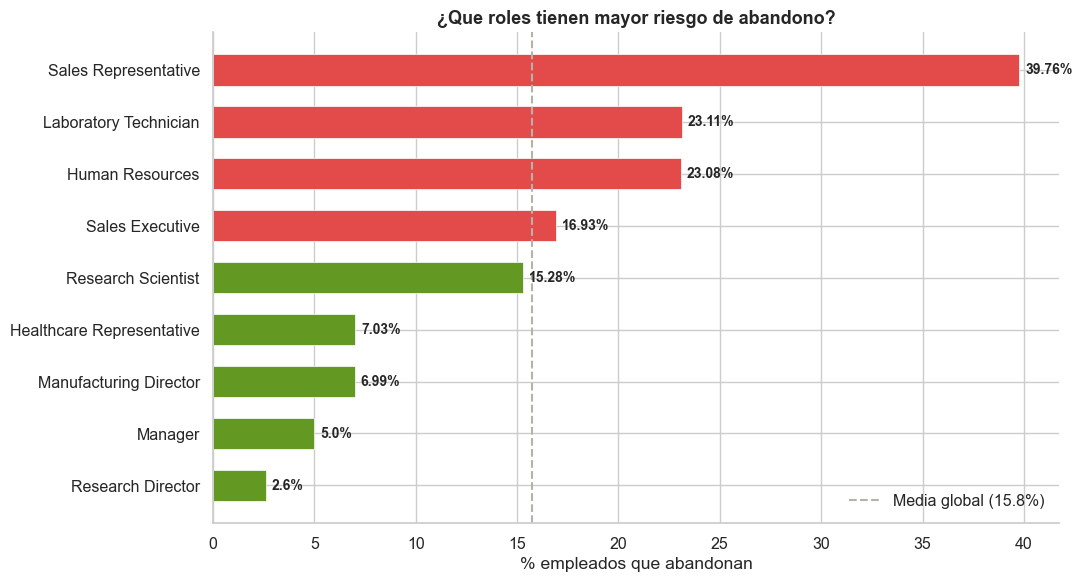

In [14]:
# PREGUNTA 4 — ¿Influye el rol?
# GRÁFICO 5 — Attrition por JobRole

# Calculamos % de attrition por rol
attrition_rol = df_grafico.groupby("JobRole")["Attrition"].mean() * 100
attrition_rol = attrition_rol.round(2).sort_values(ascending=True)

print("Attrition por rol (%):")
print(attrition_rol)

# Media global
media_global = df_grafico["Attrition"].mean() * 100

# Gráfico de barras horizontales
fig, ax = plt.subplots(figsize=(11, 6))

colores = [ROJO if v > media_global else VERDE
           for v in attrition_rol.values]

barras = ax.barh(
    attrition_rol.index,
    attrition_rol.values,
    color=colores,
    edgecolor="white",
    linewidth=0.5,
    height=0.6
)

ax.axvline(media_global, color=GRIS, linestyle="--",
           linewidth=1.5, label=f"Media global ({media_global:.1f}%)")

for barra, val in zip(barras, attrition_rol.values):
    ax.text(barra.get_width() + 0.3,
            barra.get_y() + barra.get_height() / 2,
            f"{val}%", va="center", fontweight="bold", fontsize=10)

ax.set_title("¿Que roles tienen mayor riesgo de abandono?",
             fontweight="bold", fontsize=13)
ax.set_xlabel("% empleados que abandonan")
ax.set_ylabel("")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

### Gráfico 5 — Attrition por JobRole

**Conclusión para ABC Corporation:**
Sales Representative es el rol más crítico con un 39.76%
de abandono — casi 1 de cada 2 empleados se va.
Laboratory Technician y Human Resources también superan
el 23%. En cambio los roles senior como Research Director
(2.60%) y Manager (5.00%) son los más estables.
ABC Corporation debe priorizar la retención en los roles
de nivel bajo con salarios más altos y planes de carrera.

# Gráfico 6 — Heatmap de correlaciones

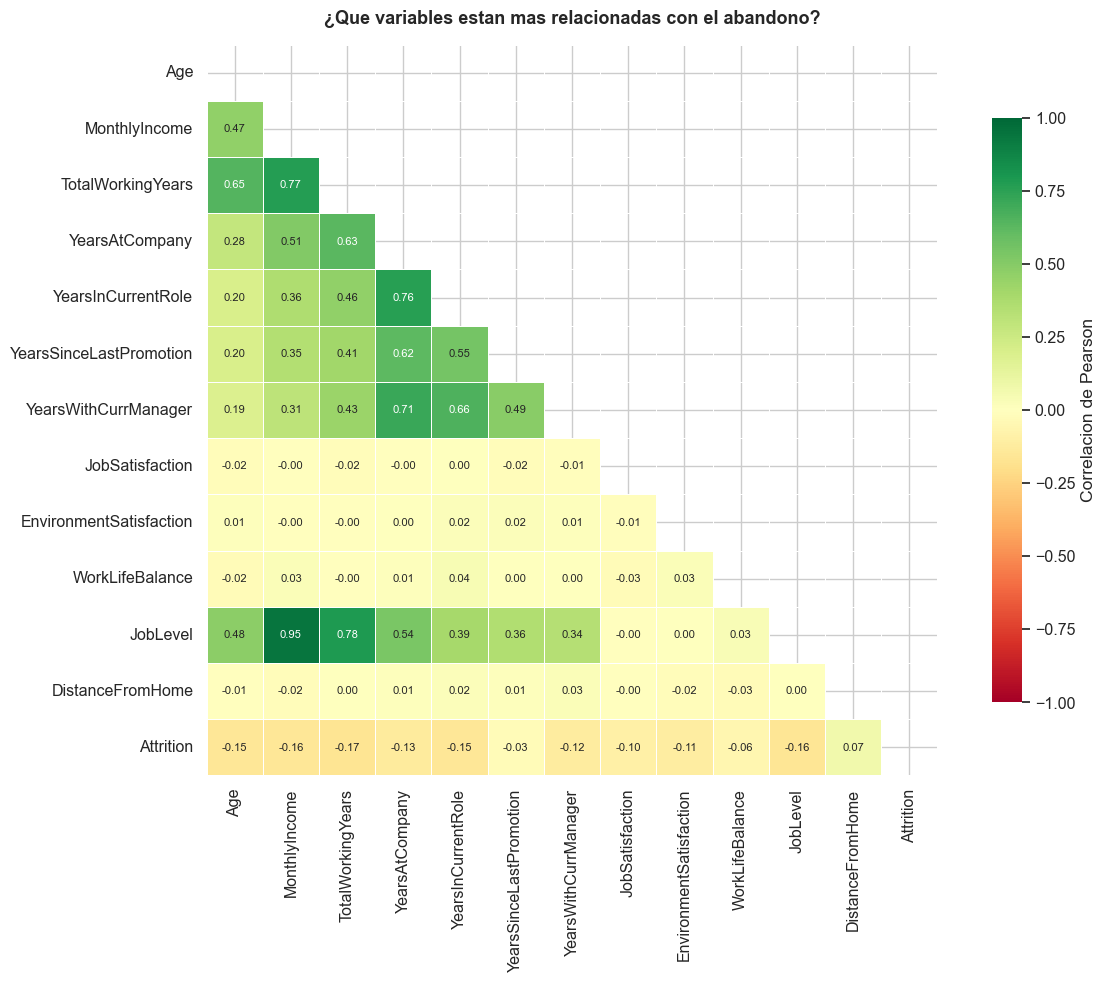


Top correlaciones con Attrition:
TotalWorkingYears          0.167
JobLevel                   0.162
MonthlyIncome              0.155
YearsInCurrentRole         0.153
Age                        0.150
YearsAtCompany             0.128
YearsWithCurrManager       0.120
EnvironmentSatisfaction    0.113
JobSatisfaction            0.101
DistanceFromHome           0.075
WorkLifeBalance            0.056
YearsSinceLastPromotion    0.031


In [15]:
# PREGUNTA 5 — ¿Qué hace que un empleado este comodo?
# GRÁFICO 6 — Heatmap de correlaciones numéricas

import numpy as np

# Seleccionamos columnas numéricas relevantes
cols_numericas = [
    "Age", "MonthlyIncome", "TotalWorkingYears",
    "YearsAtCompany", "YearsInCurrentRole",
    "YearsSinceLastPromotion", "YearsWithCurrManager",
    "JobSatisfaction", "EnvironmentSatisfaction",
    "WorkLifeBalance", "JobLevel", "DistanceFromHome",
    "Attrition"
]

# Calculamos la correlación
correlacion = df_grafico[cols_numericas].corr()

# Gráfico
fig, ax = plt.subplots(figsize=(13, 10))

mascara = np.triu(np.ones_like(correlacion, dtype=bool))

sns.heatmap(
    correlacion,
    mask=mascara,
    ax=ax,
    cmap="RdYlGn",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8,
              "label": "Correlacion de Pearson"}
)

ax.set_title("¿Que variables estan mas relacionadas con el abandono?",
             fontweight="bold", fontsize=13, pad=15)
plt.tight_layout()
plt.show()

# Top correlaciones con Attrition
print("\nTop correlaciones con Attrition:")
corr_attrition = correlacion["Attrition"].drop("Attrition")
corr_attrition = corr_attrition.abs().sort_values(ascending=False)
print(corr_attrition.round(3).to_string())

### Gráfico 6 — Heatmap de correlaciones

**Conclusión para ABC Corporation:**
Las variables con mayor correlacion negativa con Attrition son:
TotalWorkingYears (-0.167), JobLevel (-0.162) y MonthlyIncome (-0.155).
Esto confirma que los empleados con mas experiencia, mayor nivel
y mejor salario tienen menos probabilidad de abandonar.
JobSatisfaction (-0.101) y EnvironmentSatisfaction (-0.113)
tambien influyen — el bienestar importa ademas del salario.